# Part 1

In [11]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

dataset = load_iris()

X = dataset.data
y = dataset.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=15
)
scaler = StandardScaler()

y_train_binary = {}
y_test_binary = {}

for c in [0, 1, 2]:
    y_train_binary[c] = (y_train == c).astype(int)
    y_test_binary[c]  = (y_test == c).astype(int)
    
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)
for c in [0, 1, 2]:
    print(f"\nBinary target for class {c}:")
    print("train counts [0,1]:", np.bincount(y_train_binary[c]))
    print("test  counts [0,1]:", np.bincount(y_test_binary[c]))

(120, 4) (30, 4)

Binary target for class 0:
train counts [0,1]: [80 40]
test  counts [0,1]: [20 10]

Binary target for class 1:
train counts [0,1]: [80 40]
test  counts [0,1]: [20 10]

Binary target for class 2:
train counts [0,1]: [80 40]
test  counts [0,1]: [20 10]


# Part 2

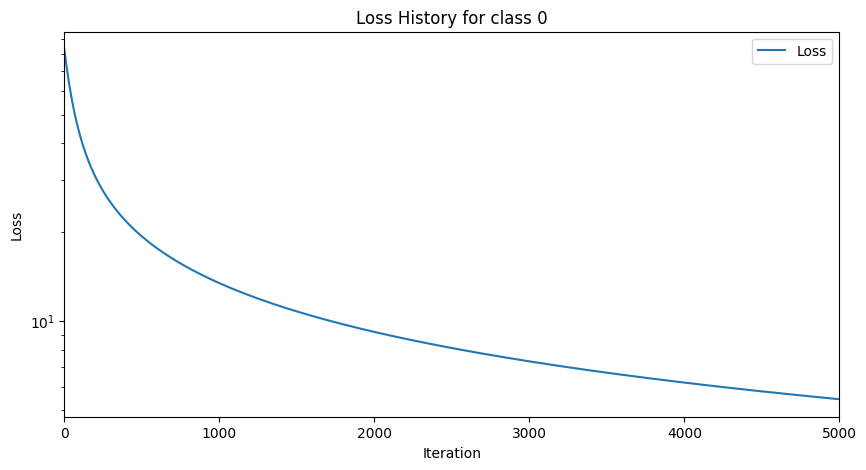

Class 0 Metrics
Train Accuracy: 1.0
Test Accuracy: 1.0
Train Loss: 5.435904818119907


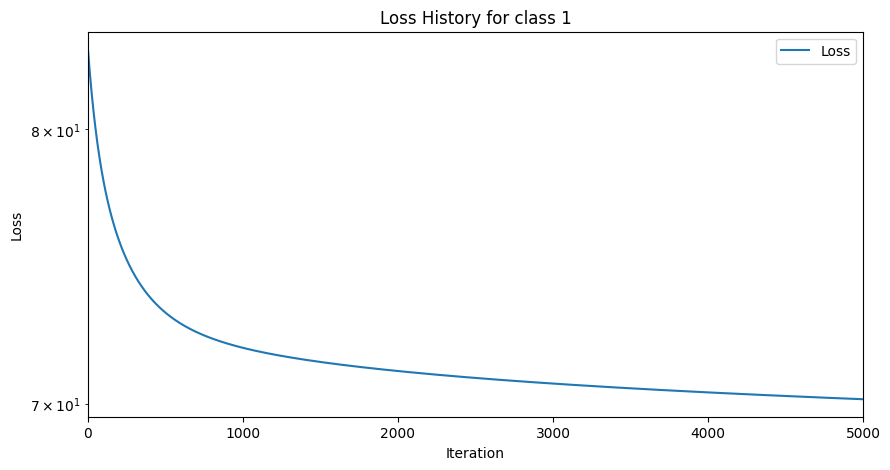

Class 1 Metrics
Train Accuracy: 0.675
Test Accuracy: 0.7333333333333333
Train Loss: 70.15759262169951


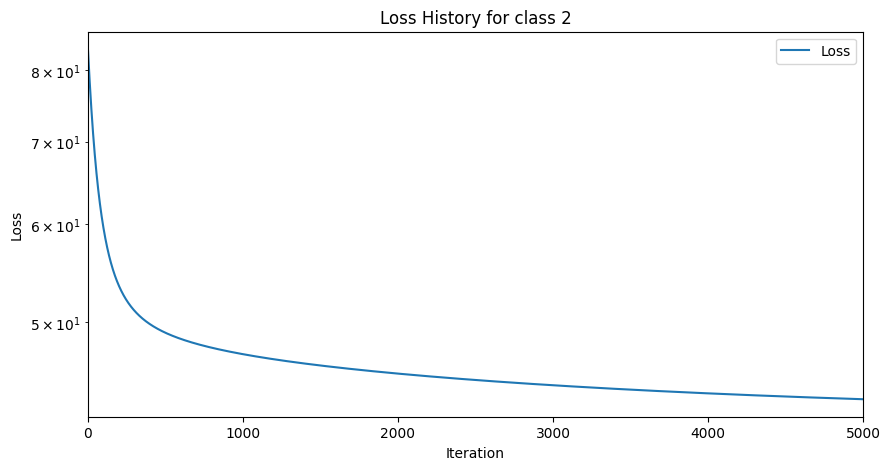

Class 2 Metrics
Train Accuracy: 0.8
Test Accuracy: 0.9333333333333333
Train Loss: 43.315745487543694


In [35]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def log_likelihood(y, w, x):
    eps=1e-12
    y_hat = sigmoid(x @ w)
    y_hat = np.clip(y_hat, eps, 1 - eps) # was running into weird numerical float issues before adding this
    return np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

def log_likelihood_gradient(y, w, x):
    y_hat = sigmoid(x @ w)
    return x.T @ (y_hat - y)

def train_logistic(x, y, lr, max_iter):
    w = np.zeros(x.shape[1])
    loss_history = []
    for i in range(max_iter):
        l = log_likelihood(y, w, x)
        loss_history.append(-1*l)
        w -= lr * log_likelihood_gradient(y, w, x)
    return w, loss_history

def plot_results(y_train_pred, y_test_pred, loss_history, c, y_train, y_test):
    plt.figure(figsize=(10, 5))
    plt.plot(loss_history, label='Loss')
    plt.xlabel('Iteration')
    plt.xlim(0, len(loss_history))
    plt.yscale('log')
    plt.ylabel('Loss')
    plt.title(f'Loss History for class {c}')
    plt.legend()
    plt.show()
    print(f"Class {c} Metrics")
    print(f"Train Accuracy: {np.mean(y_train_pred == y_train)}")
    print(f"Test Accuracy: {np.mean(y_test_pred == y_test)}")
    print(f"Train Loss: {loss_history[-1]}")

def full_train_and_test(x_train, y_train, x_test, y_test, lr, max_iter, c):
    w, loss_history = train_logistic(x_train, y_train, lr, max_iter)
    y_train_pred = (sigmoid(x_train @ w) >= 0.5).astype(int)
    y_test_pred = (sigmoid(x_test @ w) >= 0.5).astype(int)
    plot_results(y_train_pred, y_test_pred, loss_history, c, y_train, y_test)
    

for c in [0, 1, 2]:
    full_train_and_test(X_train_scaled, y_train_binary[c], X_test_scaled, y_test_binary[c], 0.0001, 5_000, c)    

# Part 3

Class 0 vs Rest
Weights: {'sepal length (cm)': np.float64(-1.6899833587661948), 'sepal width (cm)': np.float64(2.8634737301302366), 'petal length (cm)': np.float64(-5.737384277012426), 'petal width (cm)': np.float64(-4.7711099802103965)}
Top 3 features:
  petal length (cm): -5.7374
  petal width (cm): -4.7711
  sepal width (cm): 2.8635
Train Accuracy: 1.0
Test Accuracy: 1.0


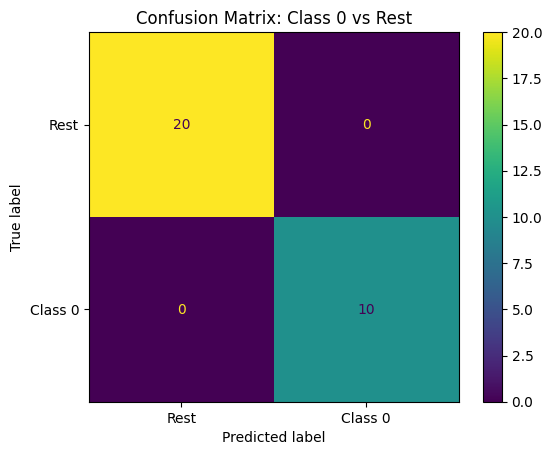

Class 1 vs Rest
Weights: {'sepal length (cm)': np.float64(-0.6727192348475929), 'sepal width (cm)': np.float64(-0.9660073197316328), 'petal length (cm)': np.float64(3.6410801490797895), 'petal width (cm)': np.float64(-2.8967911682374217)}
Top 3 features:
  petal length (cm): 3.6411
  petal width (cm): -2.8968
  sepal width (cm): -0.9660
Train Accuracy: 0.7416666666666667
Test Accuracy: 0.8333333333333334


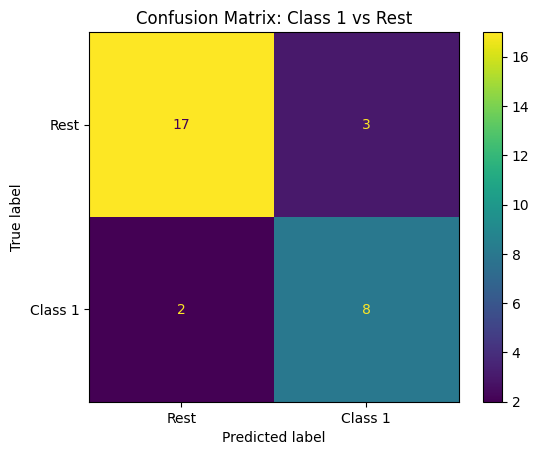

Class 2 vs Rest
Weights: {'sepal length (cm)': np.float64(-5.405448360991226), 'sepal width (cm)': np.float64(-21.621219100911496), 'petal length (cm)': np.float64(80.55954121213085), 'petal width (cm)': np.float64(139.3772316252494)}
Top 3 features:
  petal width (cm): 139.3772
  petal length (cm): 80.5595
  sepal width (cm): -21.6212
Train Accuracy: 1.0
Test Accuracy: 0.9


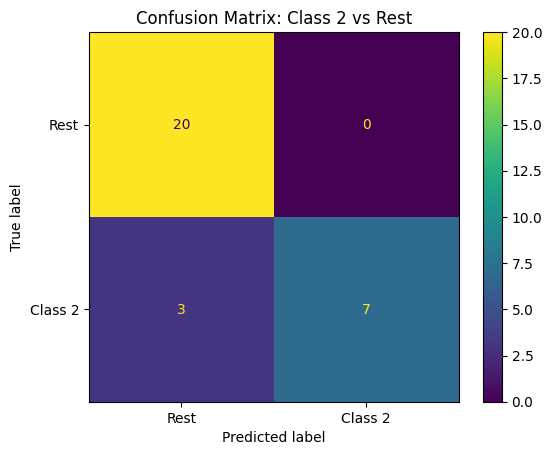

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

feature_names = dataset.feature_names

for c in [0, 1, 2]:
    model = LogisticRegression(penalty=None, max_iter=10000)
    model.fit(X_train_scaled, y_train_binary[c])
    
    weights = model.coef_[0]
    sorted_indices = np.argsort(np.abs(weights))[::-1]
    
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    print(f"Class {c} vs Rest")
    print(f"Weights: {dict(zip(feature_names, weights))}")
    print(f"Top 3 features:")
    for i in range(3):
        idx = sorted_indices[i]
        print(f"  {feature_names[idx]}: {weights[idx]:.4f}")

        
    print(f"Train Accuracy: {np.mean(y_train_pred == y_train_binary[c])}")
    print(f"Test Accuracy: {np.mean(y_test_pred == y_test_binary[c])}")
    
    cm = confusion_matrix(y_test_binary[c], y_test_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Rest", f"Class {c}"])
    disp.plot()
    plt.title(f"Confusion Matrix: Class {c} vs Rest")
    plt.show()